In [112]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [113]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize


In [114]:
kagglepath =  "../../dataset/kgdataset.csv"
surveypath = "../../dataset/survey_data.xlsx"
df = pd.read_csv(kagglepath)
df2 = pd.read_excel(surveypath)
df2.drop(df2.columns[0],axis=1, inplace=True)
df2.columns = df.columns
combined = pd.concat([df, df2], ignore_index=True)
combined


,Age,Sleep Hours,Feel Rested,Daily Screen Time,Use Before Sleep,Stress Level,Anxiety/Low Mood,Wellness Apps,Sleep Quality,Screen Time Affects Sleep?
0,47,4,Yes,11,Yes,10,No,No,Bad,Yes
1,48,4,No,8,No,7,Yes,Yes,Bad,Yes
2,40,7,Sometimes,10,No,4,No,Yes,Bad,Yes
3,26,10,Yes,5,Yes,1,Yes,No,Good,No
4,47,5,Yes,7,Yes,7,Yes,No,Good,Yes
...,...,...,...,...,...,...,...,...,...,...
1181,21,10,สดชื่น,8,ใช่,4,ไม่หงุดหงิด/ไม่วิตกกังวล,ใช่,ดี,ไม่แน่ใจ
1182,17,7-8,ไม่สดชื่น,>8ชม.,ใช่,8,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ไม่แน่ใจ
1183,17,6-8,สดชื่น,3-4,ใช่,6,ไม่หงุดหงิด/ไม่วิตกกังวล,ใช่,ไม่ดี,ใช่
1184,17,6,ไม่สดชื่น,4,ใช่,6,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ใช่


In [115]:
dfclean = pd.DataFrame(combined)
dfclean["Feel Rested"] = dfclean["Feel Rested"].replace("ไม่สดชื่น", "No").replace("สดชื่น", "Yes")
dfclean["Use Before Sleep"] = dfclean["Use Before Sleep"].replace("ไม่ใช่", "No").replace("ใช่", "Yes")
dfclean["Anxiety/Low Mood"] = dfclean["Anxiety/Low Mood"].replace("ไม่หงุดหงิด/ไม่วิตกกังวล", "No").replace("หงุดหงิด/วิตกกังวล", "Yes")
dfclean["Wellness Apps"] = dfclean["Wellness Apps"].replace("ไม่ใช่", "No").replace("ใช่", "Yes")
dfclean["Sleep Quality"] = dfclean["Sleep Quality"].replace("ไม่ดี", "Bad").replace("ดี", "Good")
dfclean["Screen Time Affects Sleep?"] = dfclean["Screen Time Affects Sleep?"].replace("ไม่แน่ใจ", "Not Sure").replace("ใช่", "Yes").replace("ไม่ใช่", "No")


In [116]:
#check for null values and duplicates
print(dfclean.isnull().sum())
duplicates = dfclean[dfclean.duplicated()]
print("Duplicate Rows:")
print(duplicates)
dfclean = dfclean.drop_duplicates()
print("DataFrame after removing duplicates:")
print(dfclean)

Age                           0
Sleep Hours                   0
Feel Rested                   0
Daily Screen Time             0
Use Before Sleep              0
Stress Level                  0
Anxiety/Low Mood              0
Wellness Apps                 0
Sleep Quality                 0
Screen Time Affects Sleep?    0
dtype: int64
Duplicate Rows:
    Age Sleep Hours Feel Rested Daily Screen Time Use Before Sleep  \
181  15          10          No                 2               No   
358  53           4   Sometimes                 9              Yes   
452  17           8          No                 4              Yes   
739  39           8   Sometimes                 2               No   
955  51          10   Sometimes                 5               No   

     Stress Level Anxiety/Low Mood Wellness Apps Sleep Quality  \
181             5               No            No          Good   
358             8               No            No           Bad   
452             3               

In [117]:
#clean age
def extract_number(value):
    if "-" in str(value):
        value = re.sub(r'[^\d\-\.]', '', value)
        values = str(value).split("-")
        return f"{values[0]}-{values[1]}"
    elif isinstance(value, str):
        result = pd.Series(value).str.extract('(\d+)') 
        return result[0].iloc[0] if not result.empty else None

    else:
        return str(value)      
dfclean["Age"] = dfclean["Age"].apply(extract_number)

#clean sleep hours by mean
def clean_range_with_mean(value):
    if isinstance(value, str):
        if '-' in value:
            try:
                low, high = map(float, value .split('-'))
                return (low + high) / 2
            except ValueError:
                return value
        else:
            try:
                return float(value)
            except ValueError:
                return value
    else:
        return value
dfclean["Sleep Hours"] = dfclean["Sleep Hours"].apply(extract_number)
dfclean["Sleep Hours"] = dfclean["Sleep Hours"].apply(clean_range_with_mean)

#Clean Daily Screen Time
dfclean["Daily Screen Time"] = dfclean["Daily Screen Time"].apply(extract_number)
dfclean["Daily Screen Time"] = dfclean["Daily Screen Time"].apply(clean_range_with_mean)
print(dfclean["Sleep Hours"].isnull().sum())
print(dfclean["Age"].isnull().sum())
print(dfclean["Daily Screen Time"].isnull().sum())


0
0
0


In [118]:
dfclean.info()


<class 'pandas.DataFrame'>
Index: 1181 entries, 0 to 1185
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         1181 non-null   str    
 1   Sleep Hours                 1181 non-null   float64
 2   Feel Rested                 1181 non-null   str    
 3   Daily Screen Time           1181 non-null   float64
 4   Use Before Sleep            1181 non-null   str    
 5   Stress Level                1181 non-null   int64  
 6   Anxiety/Low Mood            1181 non-null   str    
 7   Wellness Apps               1181 non-null   str    
 8   Sleep Quality               1181 non-null   str    
 9   Screen Time Affects Sleep?  1181 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 101.5 KB


In [119]:
df.describe()

,Age,Sleep Hours,Daily Screen Time,Stress Level
count,1100.000000,1100.000000,1100.000000,1100.000000
mean,34.813636,6.911818,6.389091,5.160909
std,11.990320,1.983197,2.650986,2.317501
min,15.000000,4.000000,2.000000,1.000000
25%,24.000000,5.000000,4.000000,3.000000
50%,35.000000,7.000000,6.000000,5.000000
75%,45.000000,9.000000,8.000000,7.000000
max,55.000000,10.000000,12.000000,10.000000


Text(0.5, 1.0, 'Distribution of Screen Time Affects Sleep?')

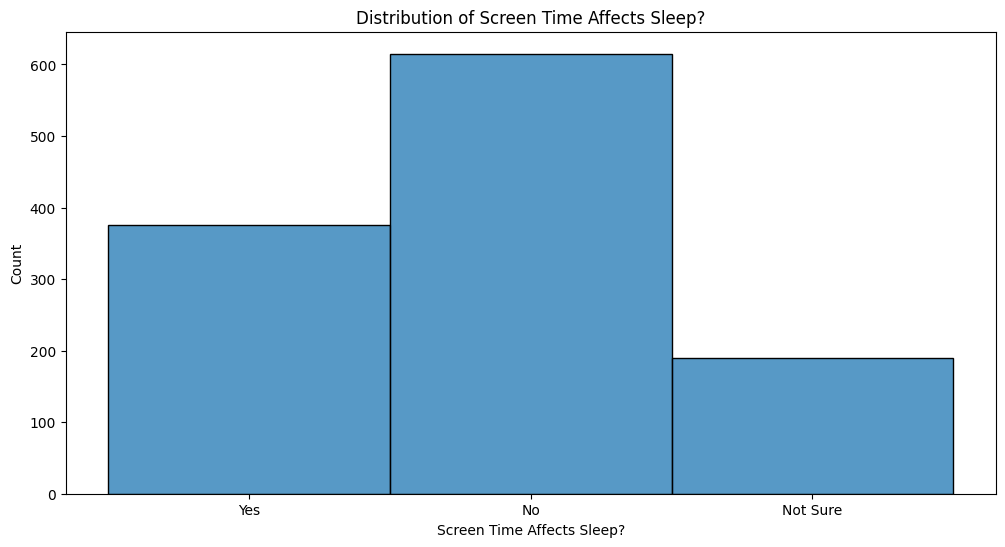

In [120]:
plt.figure(figsize=(12, 6))
sns.histplot(dfclean['Screen Time Affects Sleep?'], kde=False)
plt.title('Distribution of Screen Time Affects Sleep?')

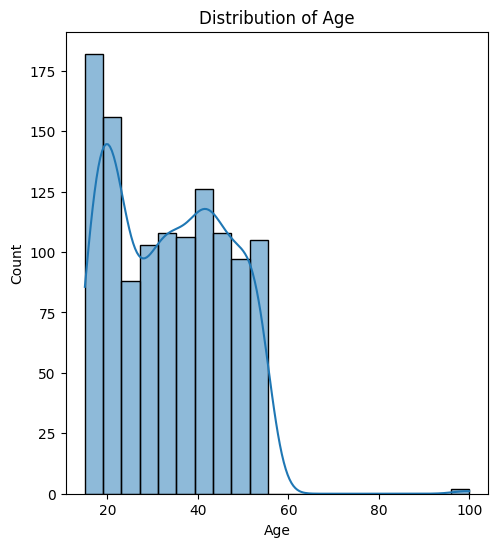

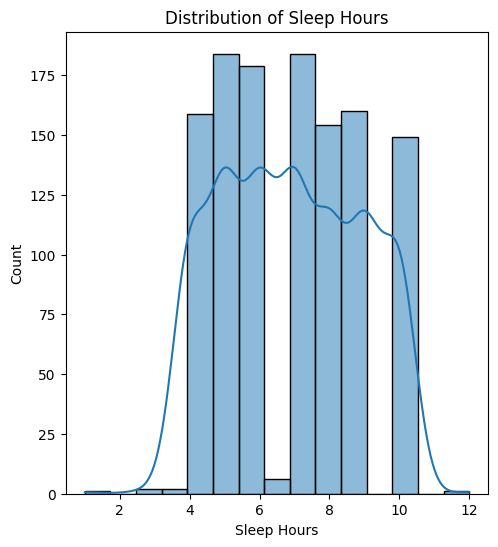

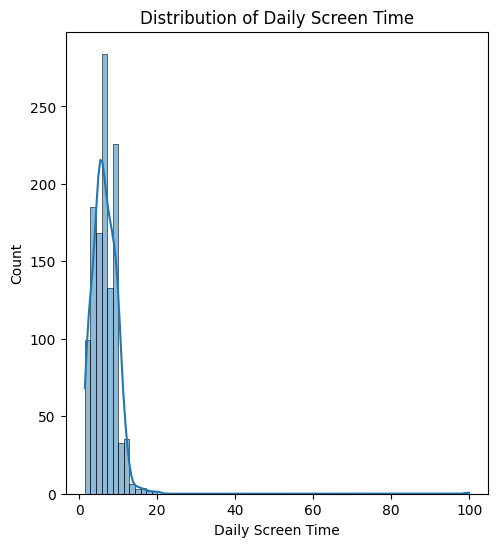

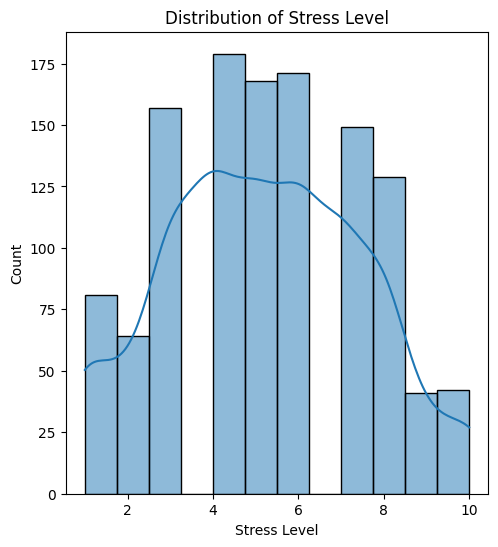

In [121]:
dfclean["Age"] = pd.to_numeric(dfclean["Age"], errors='coerce')
numeric_cols = dfclean.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(dfclean[col], kde=True)
    plt.title(f'Distribution of {col}')

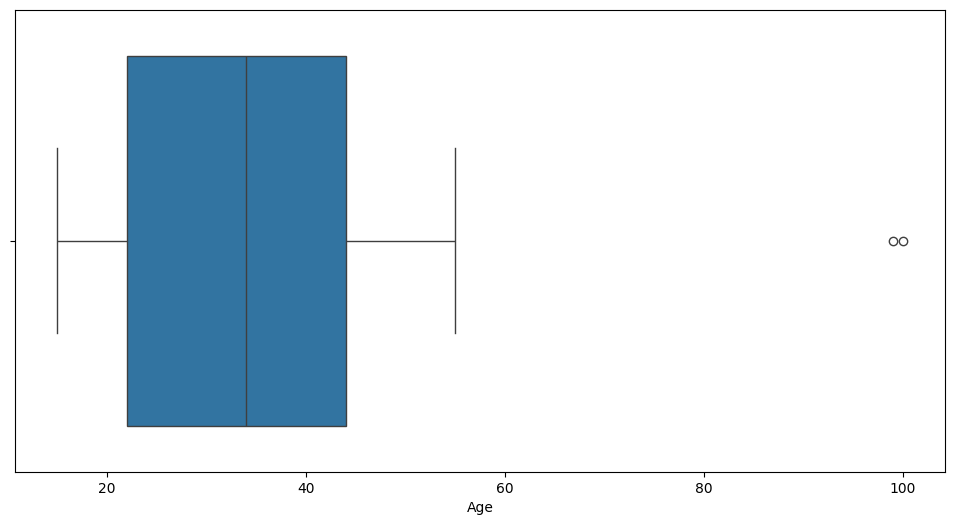

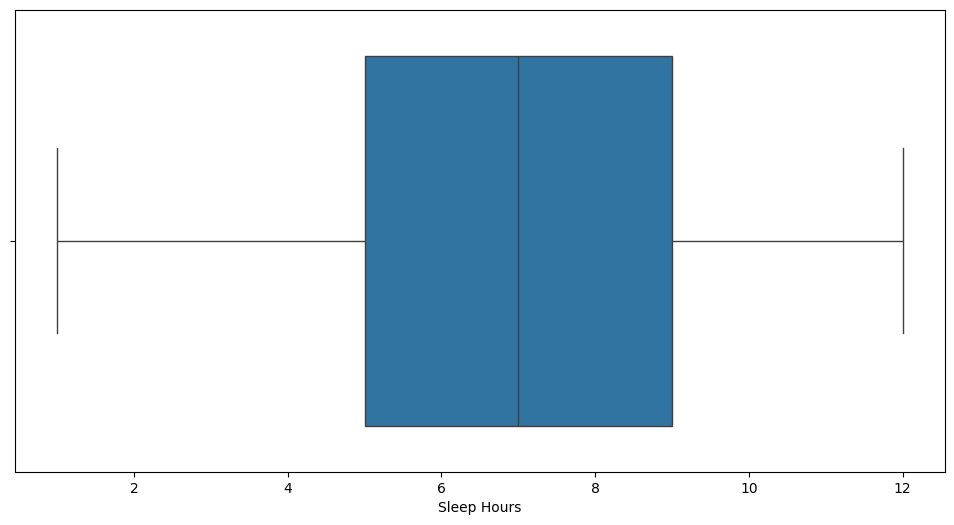

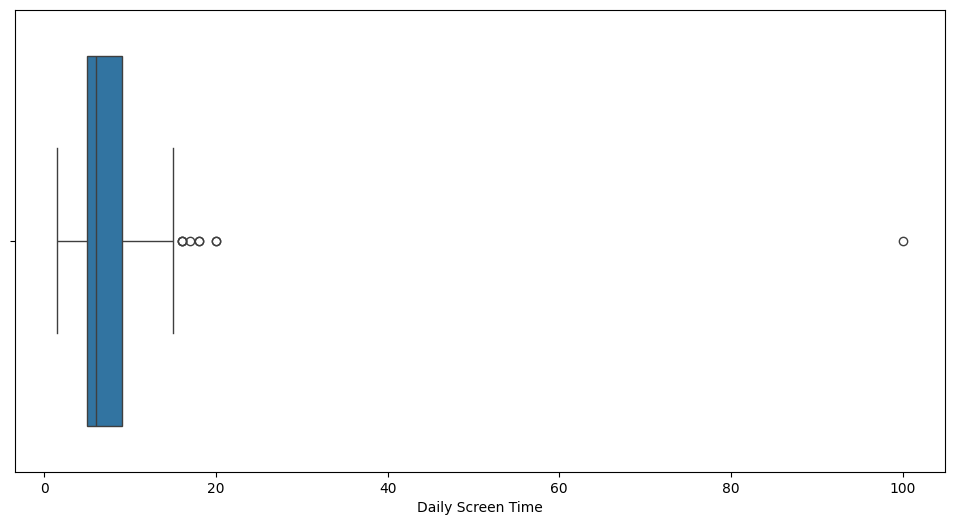

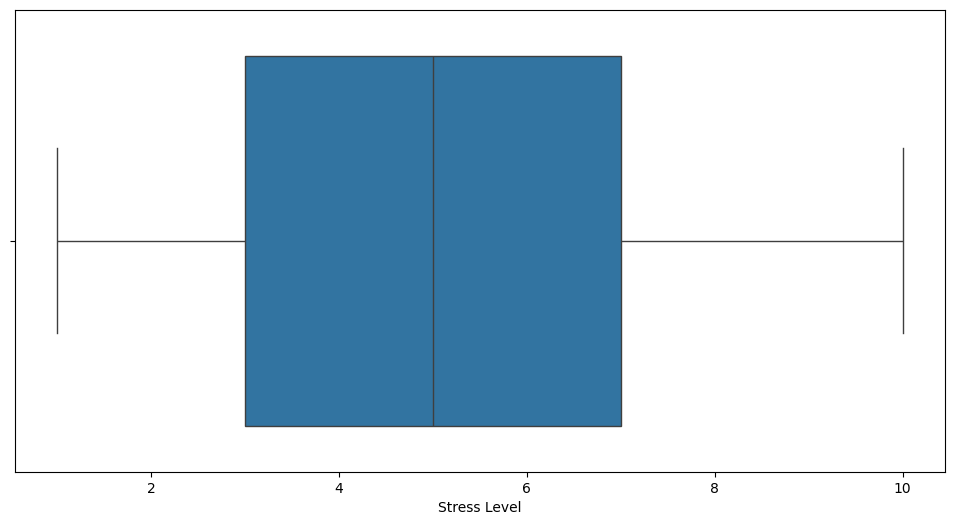

In [122]:
for col in numeric_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=dfclean[col])

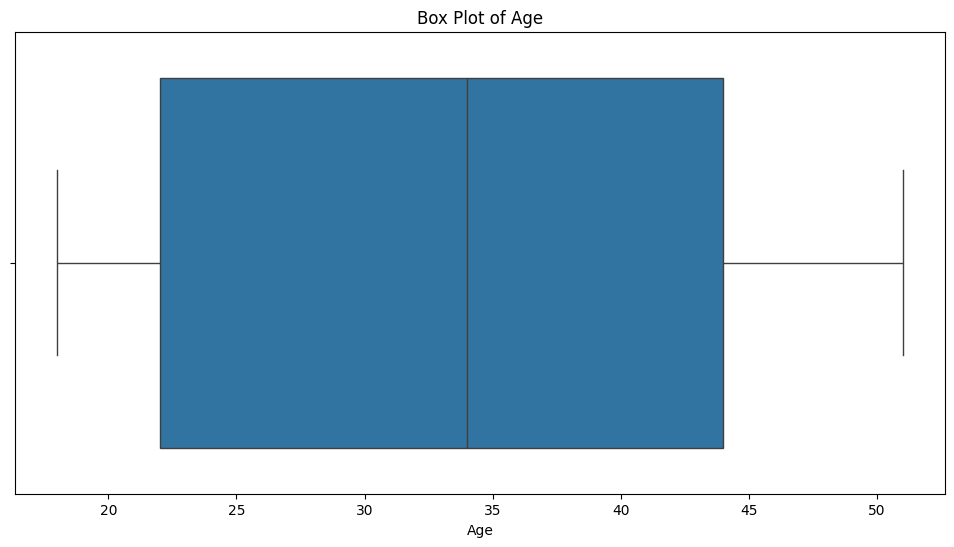

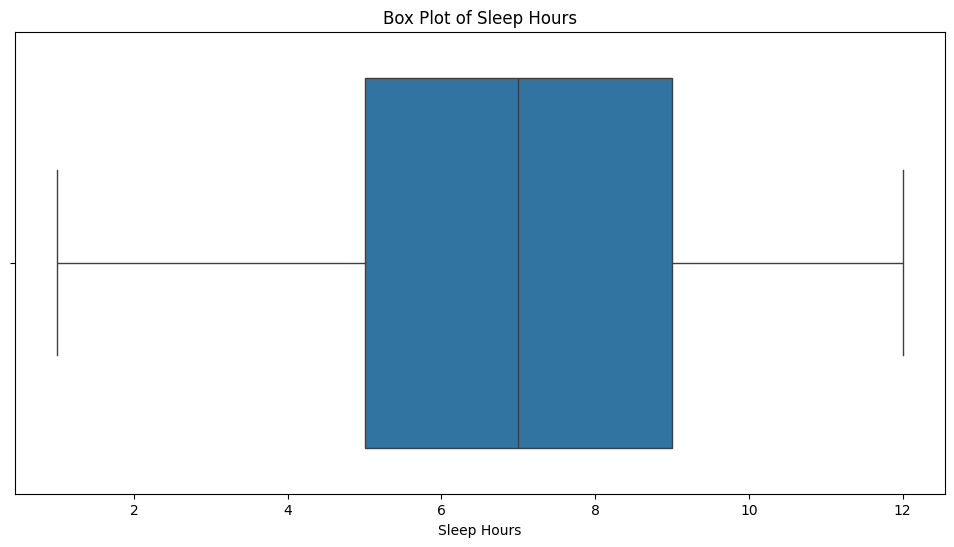

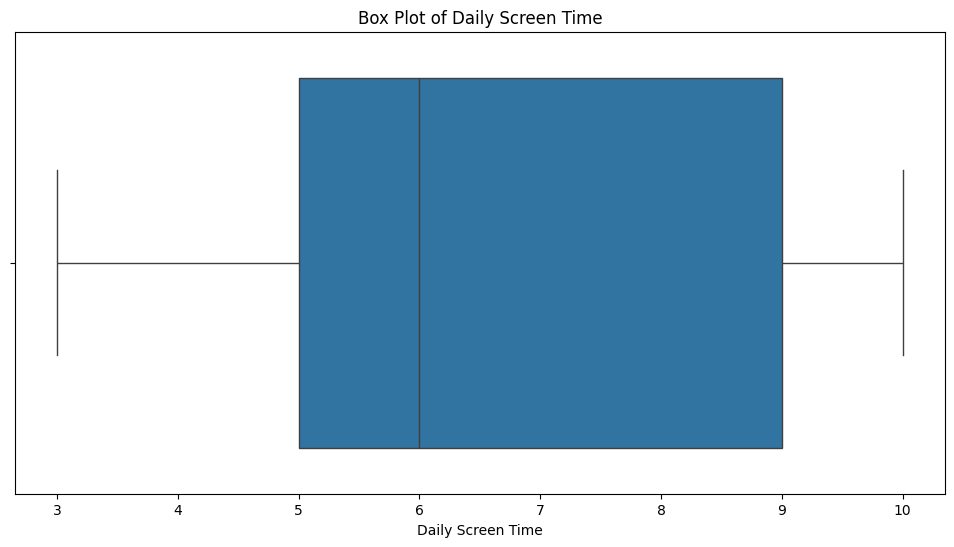

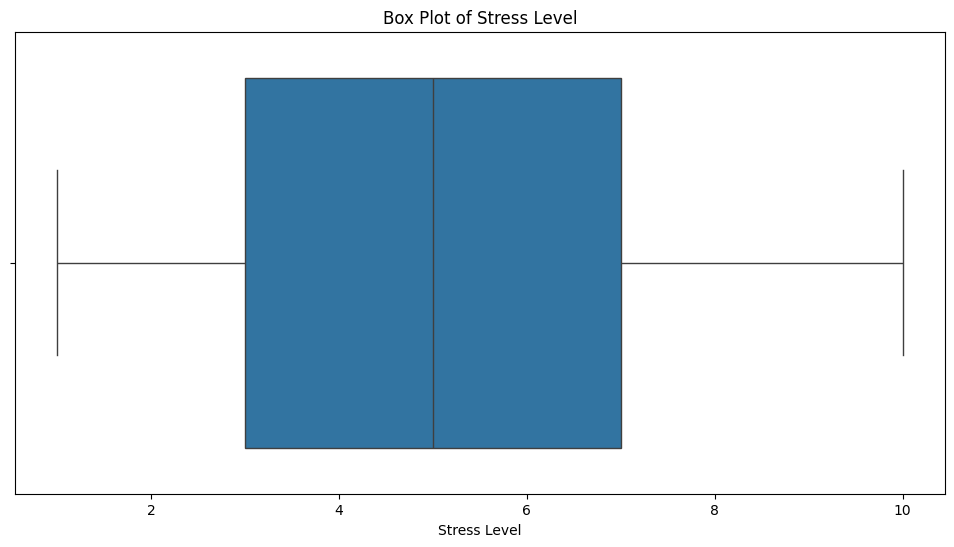

In [123]:
dfclean['Daily Screen Time'] = winsorize(dfclean['Daily Screen Time'],(0.1, 0.1))
dfclean['Age'] = winsorize(dfclean['Age'],(0.1, 0.1))

for col in numeric_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=dfclean[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

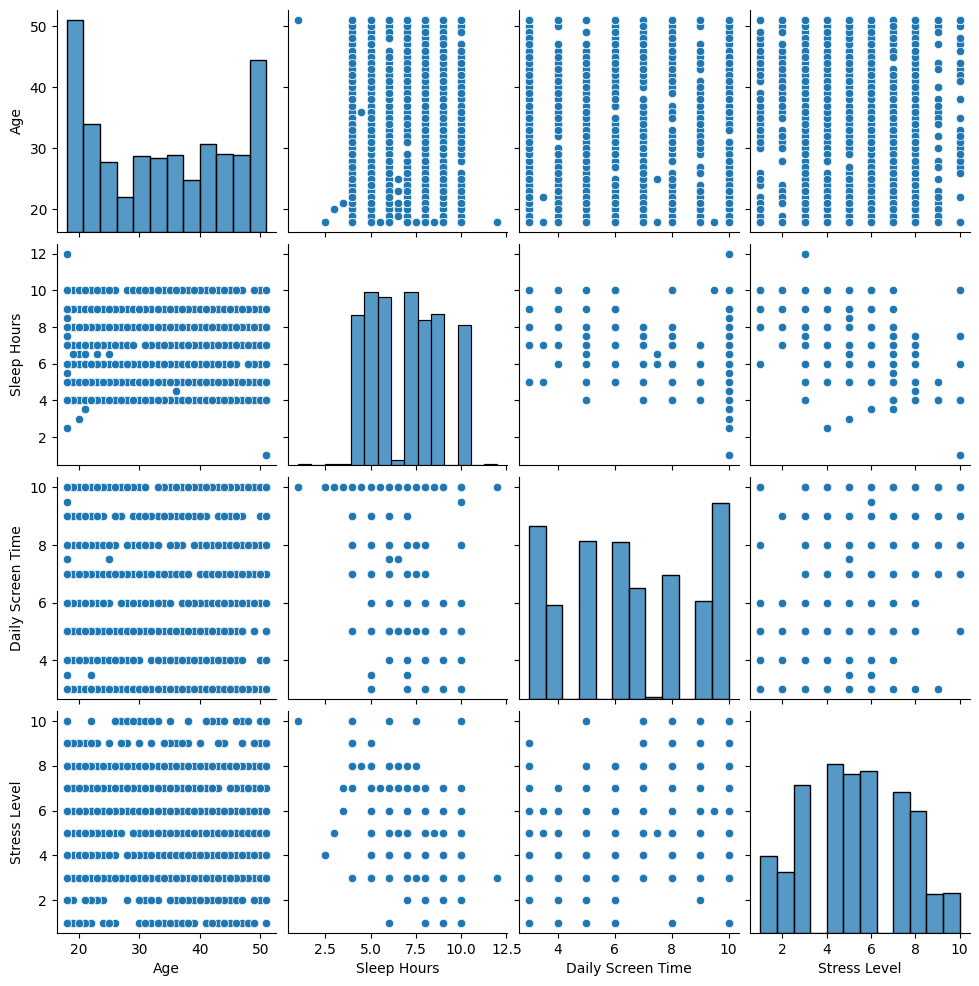

In [124]:
sns.pairplot(dfclean[numeric_cols])
plt.show()

<Axes: xlabel='Daily Screen Time', ylabel='Sleep Hours'>

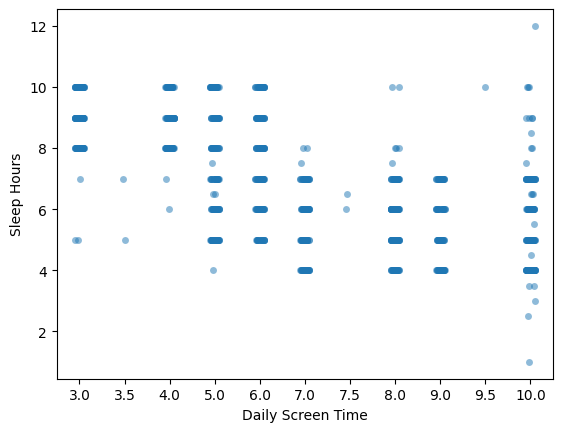

In [125]:
sns.stripplot(data=dfclean, x="Daily Screen Time", y="Sleep Hours", jitter=True, alpha=0.5)

C:\Users\title\AppData\Local\Temp\ipykernel_22052\614845954.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = dfclean.select_dtypes(include=['object']).columns


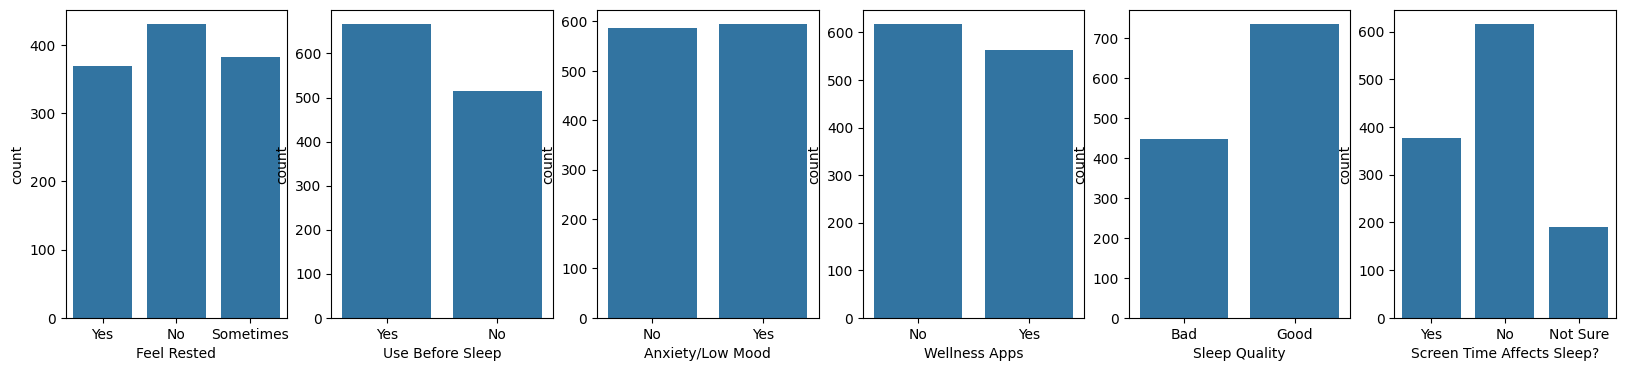

In [143]:
cat_cols = dfclean.select_dtypes(include=['object']).columns
enumerated_cat_cols = list(enumerate(cat_cols))
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(20, 4))
for i, col in enumerated_cat_cols:
    sns.countplot(data=dfclean, x=col, ax=axes[i])

<Axes: xlabel='Use Before Sleep', ylabel='Sleep Hours'>

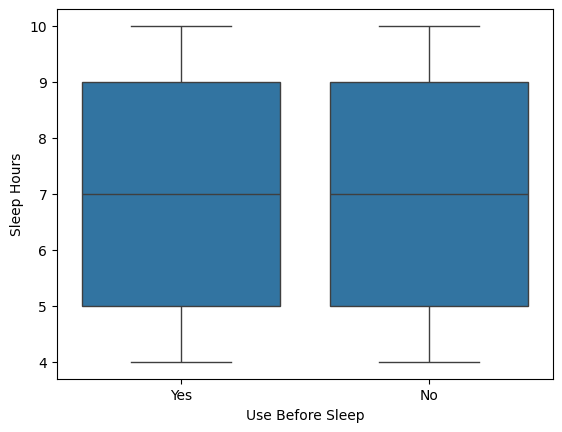

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(20, 4))
sns.boxplot(data=df, x="Use Before Sleep", y="Sleep Hours", ax=axes[0])
sns.boxplot(data=df, x="Sleep Quality", y="Sleep Hours", ax=axes[1])
sns.boxplot(data=df, x="Anxiety/Low Mood", y="Sleep Hours", ax=axes[2])


<Axes: xlabel='Feel Rested', ylabel='Sleep Hours'>

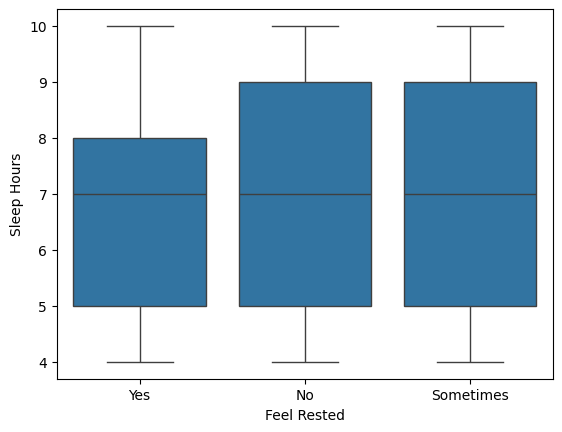

In [149]:
sns.boxplot(data=df, x="Feel Rested", y="Sleep Hours")


<Axes: >

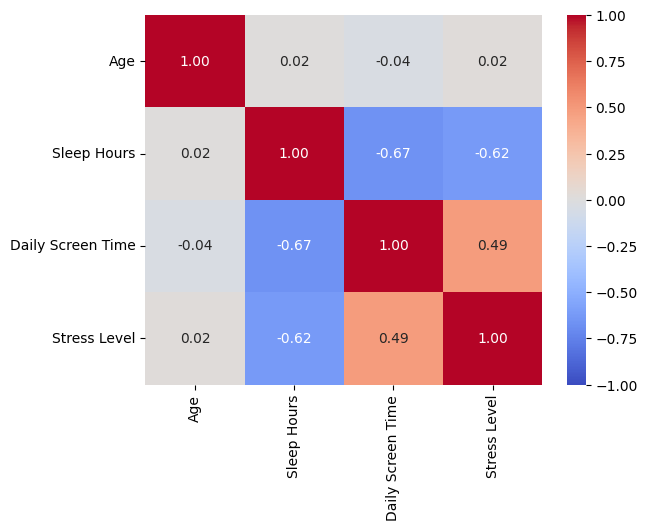

In [151]:
numeric_data = dfclean.select_dtypes(include=['number'])
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)

